# 03 · Feature Engineering

Three families:

| Family | Examples |
|---|---|
| **Time** | year, month, quarter, season, month index, Fourier harmonics, academic-calendar flags |
| **Historical** | lags 1/2/3/6/12, rolling mean/std, MoM & YoY growth, trend slope, same-month mean |
| **Operational** | funnel conversion, realizations, product mix, entity concentration (HHI) |

**The core design decision:** one function, `compute_feature_row`, builds a feature
vector — and it is used for *both* the training matrix and every step of the recursive
forecast. Train/serve skew becomes structurally impossible rather than merely avoided.

In [1]:
import sys, warnings
from pathlib import Path

# Make the project root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from src.config import get_settings, configure_logging

settings = get_settings()
configure_logging(settings, "WARNING")
print("Project root:", ROOT)
print("MC:", settings.mc_name, "| target:", settings.target, "| forecast year:", settings.forecast_year)

Project root: /Users/jayedalammansur/Exchange Activity Prediction Platform
MC: AIESEC in India | target: APP | forecast year: 2026


In [2]:
from src.preprocessing.cleaning import load_exchange_dataset
from src.preprocessing import features as F

panel = load_exchange_dataset(settings)
target = settings.target

monthly = panel.groupby("date", as_index=False)[target].sum().sort_values("date")
series = pd.Series(monthly[target].to_numpy(dtype=float),
                   index=pd.DatetimeIndex(monthly["date"]), name=target)
print(f"{len(series)} months: {series.index.min():%Y-%m} -> {series.index.max():%Y-%m}")
series.head()

48 months: 2022-01 -> 2025-12


date
2022-01-01    841.0
2022-02-01    672.0
2022-03-01    725.0
2022-04-01    745.0
2022-05-01    969.0
Name: APP, dtype: float64

## 1. Time features

All knowable arbitrarily far ahead — which is what makes a 12-month forecast possible.

In [3]:
row = F.compute_feature_row(series, pd.Timestamp("2025-12-01"), series.index[0])
time_keys = ["year", "month", "quarter", "season_code", "month_index",
             "month_sin", "month_cos", "month_sin2", "month_cos2",
             "is_break_season", "is_exam_season", "is_semester_start",
             "is_year_end", "days_in_month"]
pd.Series({k: row[k] for k in time_keys}, name="Dec 2025").to_frame()

,Dec 2025
year,2.025000e+03
month,1.200000e+01
quarter,4.000000e+00
season_code,0.000000e+00
month_index,4.700000e+01
month_sin,-2.449294e-16
month_cos,1.000000e+00
month_sin2,-4.898587e-16
month_cos2,1.000000e+00
is_break_season,1.000000e+00


### Why Fourier terms instead of month dummies

Two harmonics express smooth annual seasonality with **4 parameters** instead of the
**11** an 11-dummy encoding would need — materially more sample-efficient on 48 rows.

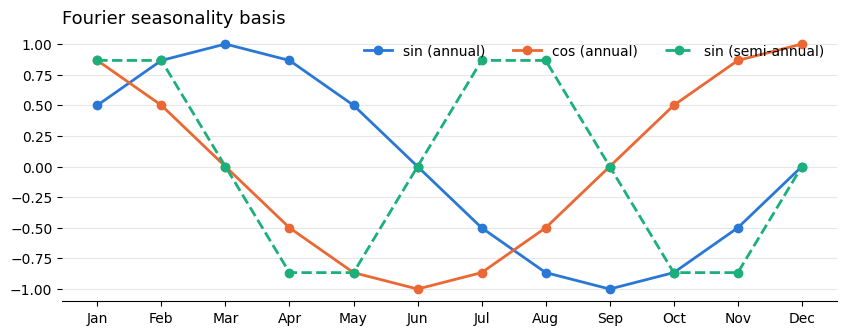

Indian academic calendar encoding:
  break months (travel)  : [1, 5, 6, 12]
  exam months (dip)      : [3, 4, 11]
  semester starts        : [1, 7, 8]


In [4]:
months = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(months, np.sin(2 * np.pi * months / 12), marker="o", linewidth=2,
        color="#2a78d6", label="sin (annual)")
ax.plot(months, np.cos(2 * np.pi * months / 12), marker="o", linewidth=2,
        color="#eb6834", label="cos (annual)")
ax.plot(months, np.sin(4 * np.pi * months / 12), marker="o", linewidth=2,
        color="#1baf7a", linestyle="--", label="sin (semi-annual)")
ax.set_xticks(months)
ax.set_xticklabels([pd.Timestamp(2024, m, 1).strftime("%b") for m in months])
ax.set_title("Fourier seasonality basis", loc="left", fontsize=13)
ax.legend(frameon=False, ncols=3)
ax.grid(axis="y", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

print("Indian academic calendar encoding:")
print("  break months (travel)  :", sorted(F.BREAK_MONTHS))
print("  exam months (dip)      :", sorted(F.EXAM_MONTHS))
print("  semester starts        :", sorted(F.SEMESTER_START_MONTHS))

## 2. Historical features

In [5]:
hist_keys = [k for k in row if k.startswith(("lag_", "roll_")) or k in
             ("mom_growth", "yoy_growth", "lag1_over_lag12", "lag1_over_roll12",
              "trend_slope_6", "same_month_mean")]
pd.Series({k: round(row[k], 2) for k in hist_keys}, name="Dec 2025").to_frame()

,Dec 2025
lag_1,1569.00
lag_2,1482.00
lag_3,1331.00
lag_6,1894.00
lag_12,1976.00
roll_mean_3,1460.67
roll_std_3,120.43
roll_mean_6,1516.83
roll_std_6,210.48
roll_mean_12,1521.25


## 3. Operational features

Every one is **shifted forward one month**, so the model only ever sees operational
state that was actually observable before the month it predicts.

In [6]:
operational = F.build_operational_features(panel, settings)
operational.tail(6).round(3)

,op_app_to_re_pct,op_app_to_ach_pct,op_realizations,op_outgoing_share,op_gv_share,op_entity_hhi,op_active_entities
date,,,,,,,
2025-07-01,20.433,44.351,387.0,72.122,69.958,0.078,20.0
2025-08-01,21.523,45.430,325.0,68.477,68.146,0.073,20.0
2025-09-01,20.076,45.247,264.0,68.745,68.973,0.076,20.0
2025-10-01,21.112,45.379,281.0,75.958,68.670,0.075,20.0
2025-11-01,20.850,44.399,309.0,77.058,67.611,0.075,20.0
2025-12-01,19.949,45.698,313.0,74.379,67.559,0.072,20.0


## 4. ⚠️ The no-leakage guarantee

The single most important correctness property in the pipeline. If features for month
*t* depend on the value *at* t — or on anything after it — every reported metric is
optimistic and the model is useless in production.

Two checks below. Both must show **identical**.

In [7]:
probe_date = series.index[30]

baseline = F.compute_feature_row(series, probe_date, series.index[0])

# (a) Mutate the value AT the target month.
tampered = series.copy()
tampered.loc[probe_date] = 999_999.0
mutated_target = F.compute_feature_row(tampered, probe_date, series.index[0])

# (b) Mutate everything AFTER the target month.
future = series.copy()
future.iloc[31:] = 999_999.0
mutated_future = F.compute_feature_row(future, probe_date, series.index[0])

print("Target-month mutation :", "identical ✅" if baseline == mutated_target else "LEAK ❌")
print("Future mutation       :", "identical ✅" if baseline == mutated_future else "LEAK ❌")

Target-month mutation : identical ✅
Future mutation       : identical ✅


## 5. Build the training matrix

In [8]:
frame = F.build_training_frame(panel, settings, save=True)
print("shape:", frame.shape, "->", frame.shape[1] - 2, "features,", len(frame), "rows")
print("NaNs :", int(frame.isna().sum().sum()))
frame.head()

shape: (36, 42) -> 40 features, 36 rows
NaNs : 0


,date,y,year,month,quarter,season_code,month_index,month_sin,month_cos,month_sin2,month_cos2,is_break_season,is_exam_season,is_semester_start,is_year_end,days_in_month,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,roll_max_12,roll_min_12,mom_growth,yoy_growth,lag1_over_lag12,lag1_over_roll12,trend_slope_6,same_month_mean,op_app_to_re_pct,op_app_to_ach_pct,op_realizations,op_outgoing_share,op_gv_share,op_entity_hhi,op_active_entities
0,2023-01-01,1269.0,2023.0,1.0,1.0,0.0,12.0,0.500000,8.660254e-01,8.660254e-01,0.5,1.0,0.0,1.0,0.0,31.0,1066.0,916.0,748.0,760.0,841.0,910.000000,159.084883,823.000000,140.581649,821.166667,127.488205,1066.0,672.0,16.375546,0.000000,1.267539,1.298153,62.628571,841.0,19.324578,46.998124,206.0,74.015009,66.791745,0.072787,20.0
1,2023-02-01,896.0,2023.0,2.0,1.0,0.0,13.0,0.866025,5.000000e-01,8.660254e-01,-0.5,0.0,0.0,0.0,0.0,28.0,1269.0,1066.0,916.0,693.0,672.0,1083.666667,177.161885,907.833333,223.867297,856.833333,181.829507,1269.0,672.0,19.043152,50.891795,1.888393,1.481035,113.742857,672.0,16.942474,42.553191,215.0,72.104019,69.582348,0.071597,20.0
2,2023-03-01,1030.0,2023.0,3.0,1.0,1.0,14.0,1.000000,6.123234e-17,1.224647e-16,-1.0,0.0,1.0,0.0,0.0,31.0,896.0,1269.0,1066.0,755.0,725.0,1077.000000,186.743139,941.666667,198.847345,875.500000,172.381975,1269.0,693.0,-29.393223,33.333333,1.235862,1.023415,69.085714,725.0,19.754464,46.875000,177.0,75.334821,67.633929,0.070522,20.0
3,2023-04-01,1167.0,2023.0,4.0,2.0,1.0,15.0,0.866025,-5.000000e-01,-8.660254e-01,-0.5,0.0,1.0,0.0,0.0,30.0,1030.0,896.0,1269.0,748.0,745.0,1065.000000,188.947083,987.500000,177.795107,900.916667,170.650871,1269.0,693.0,14.955357,42.068966,1.382550,1.143280,44.371429,745.0,20.000000,45.533981,206.0,76.019417,68.155340,0.068838,20.0
4,2023-05-01,1450.0,2023.0,5.0,2.0,2.0,16.0,0.500000,-8.660254e-01,-8.660254e-01,0.5,1.0,0.0,0.0,0.0,31.0,1167.0,1030.0,896.0,916.0,969.0,1031.000000,135.502767,1057.333333,143.982869,936.083333,178.882622,1269.0,693.0,13.300971,56.644295,1.204334,1.246684,22.114286,969.0,20.394173,43.873179,238.0,75.235647,69.408740,0.078678,20.0


### Sample size reality check

36 usable rows against 40 features. This ratio is exactly why the modelling notebook
compares four tiers instead of reaching for the highest-capacity model — regularisation
is likely to beat capacity here, and the backtest will settle it.

In [9]:
n_rows, n_features = len(frame), frame.shape[1] - 2
print(f"rows/features = {n_rows}/{n_features} = {n_rows / n_features:.2f}")
print("\nA high-capacity learner will overfit this. Let the walk-forward backtest decide.")

rows/features = 36/40 = 0.90

A high-capacity learner will overfit this. Let the walk-forward backtest decide.


## 6. Which features correlate with the target?

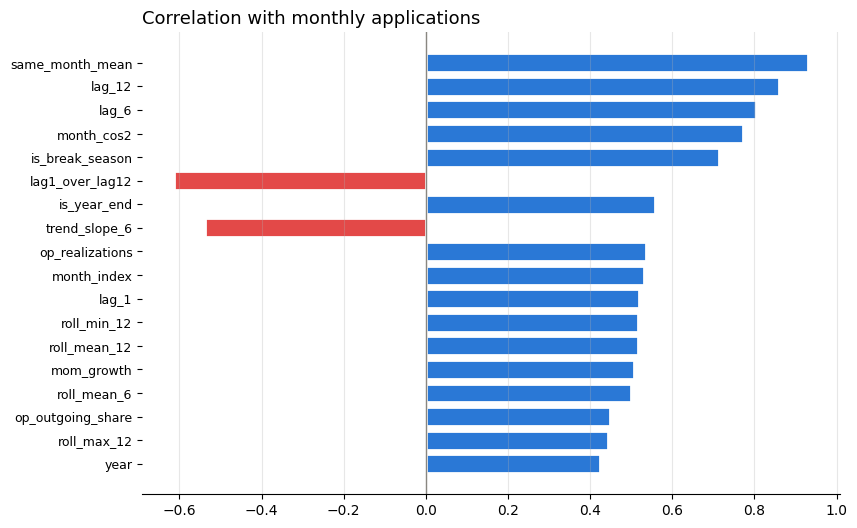

,correlation
same_month_mean,0.930
lag_12,0.859
lag_6,0.804
month_cos2,0.772
is_break_season,0.714
lag1_over_lag12,-0.614
is_year_end,0.559
trend_slope_6,-0.537
op_realizations,0.535
month_index,0.530


In [10]:
correlations = (frame.drop(columns=["date"]).corr()["y"]
                .drop("y").sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = correlations.head(18).iloc[::-1]
ax.barh(top.index, top.values,
        color=["#2a78d6" if v > 0 else "#e34948" for v in top.values],
        edgecolor="white", linewidth=2)
ax.axvline(0, color="#898781", linewidth=1)
ax.set_title("Correlation with monthly applications", loc="left", fontsize=13)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

correlations.head(10).round(3).to_frame("correlation")

**Next:** `04_model_training.ipynb`